In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("renewable_energy_dataset.csv")
df.head()

,State,Year,Installed - Bio-Mass Power,Installed - Small Hydro Power,Installed - Solar Power,Installed - Wind Power,Zone,Installed - Waste to Energy,Population,GSDP (crore INR)
0,Andaman And Nicobar Islands,2006,0.0,5.25,0.1,0.0,South,0.0,366589.0,3114.06
1,Andaman And Nicobar Islands,2007,0.0,5.25,0.1,1.1,South,0.0,369517.0,3114.06
2,Andaman And Nicobar Islands,2008,0.0,5.25,0.1,1.1,South,0.0,372344.0,3114.06
3,Andaman And Nicobar Islands,2009,0.0,5.25,0.1,0.0,South,0.0,375072.0,3114.06
4,Andaman And Nicobar Islands,2010,0.0,5.25,0.1,0.0,South,0.0,377699.0,3114.06


**Dataset Overview**

Column Name        Description  
State              Name of the Indian        of terretory   

Year

GSDP

Population

Solat Wind

Small Hydro

Bio mass

Waste to Energy

In [ ]:

df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   State                          635 non-null    object 
 1   Year                           635 non-null    int64  
 2   Installed - Bio-Mass Power     635 non-null    float64
 3   Installed - Small Hydro Power  635 non-null    float64
 4   Installed - Solar Power        635 non-null    float64
 5   Installed - Wind Power         635 non-null    float64
 6   Zone                           635 non-null    object 
 7   Installed - Waste to Energy    635 non-null    float64
 8   Population                     635 non-null    float64
 9   GSDP (crore INR)               635 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 49.7+ KB


,0
State,0
Year,0
Installed - Bio-Mass Power,0
Installed - Small Hydro Power,0
Installed - Solar Power,0
Installed - Wind Power,0
Zone,0
Installed - Waste to Energy,0
Population,0
GSDP (crore INR),0


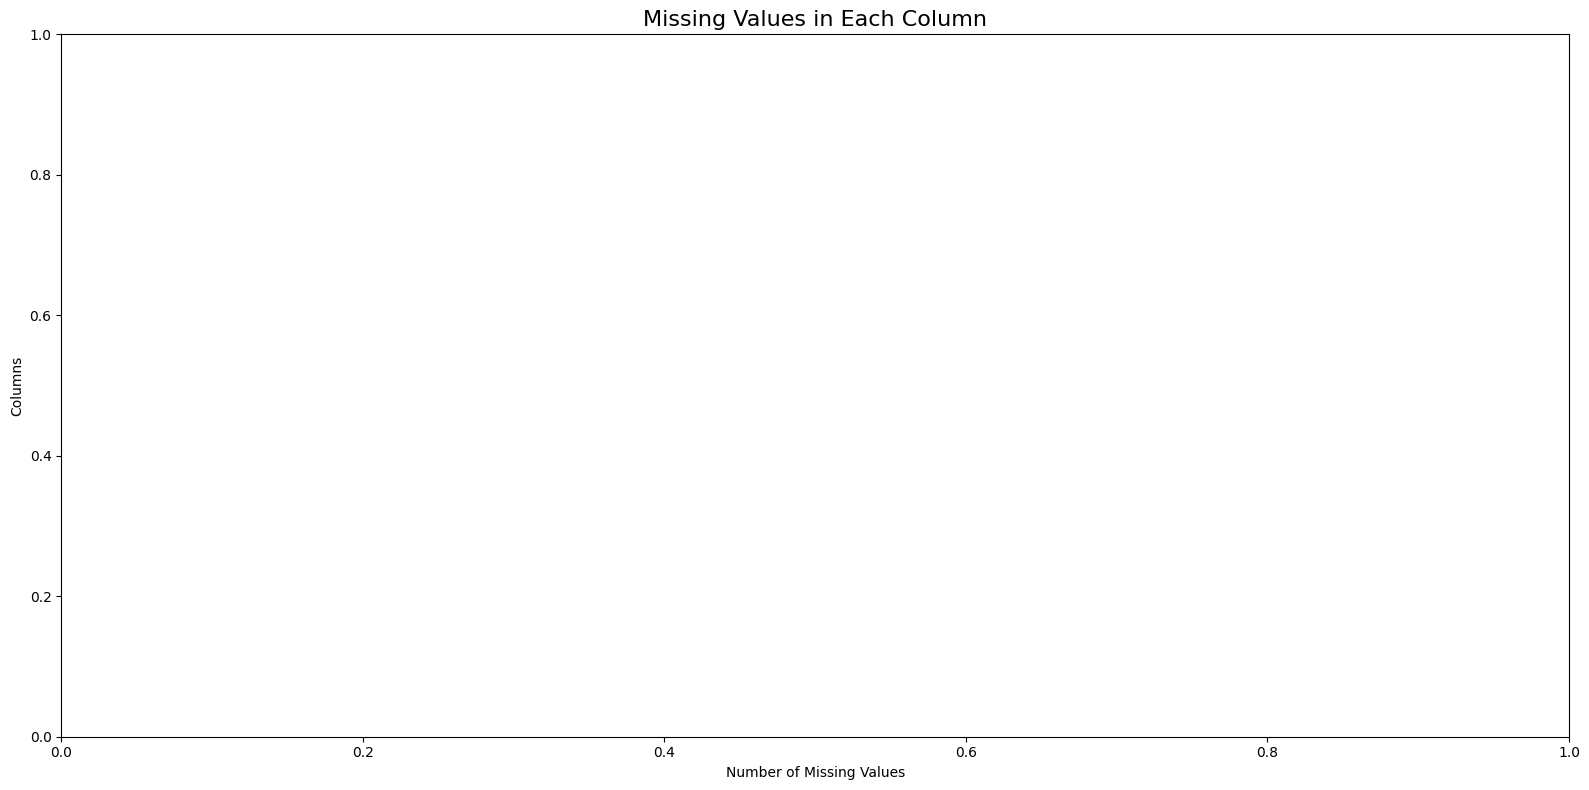

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count missing values
missing = df.isnull().sum()

# Keep only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(16,8))

sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="viridis"
)

plt.title("Missing Values in Each Column", fontsize=16)
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop('Year')

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

df.isnull().sum()

,0
State,0
Year,0
Installed - Bio-Mass Power,0
Installed - Small Hydro Power,0
Installed - Solar Power,0
Installed - Wind Power,0
Zone,0
Installed - Waste to Energy,0
Population,0
GSDP (crore INR),0


In [ ]:
print(df.columns)

Index(['State', 'Year', 'Installed - Bio-Mass Power',
       'Installed - Small Hydro Power', 'Installed - Solar Power',
       'Installed - Wind Power', 'Zone', 'Installed - Waste to Energy',
       'Population', 'GSDP (crore INR)'],
      dtype='object')


In [ ]:
df = pd.get_dummies(df,
                    columns=cat_cols,
                    drop_first=True)

In [ ]:
print(df.describe)
df.shape

<bound method NDFrame.describe of      Year  Installed - Bio-Mass Power  Installed - Small Hydro Power  \
0    2006                    0.000000                       5.250000   
1    2007                    0.000000                       5.250000   
2    2008                    0.000000                       5.250000   
3    2009                    0.000000                       5.250000   
4    2010                    0.000000                       5.250000   
..    ...                         ...                            ...   
630  2020                  319.920000                      98.500000   
631  2021                  319.920000                      98.500000   
632  2022                  319.919708                      98.499748   
633  2023                  319.919708                      98.499748   
634  2024                  319.919708                      98.499748   

     Installed - Solar Power  Installed - Wind Power  \
0                   0.100000                0

(635, 46)

In [ ]:
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
df.shape

(635, 46)